## Preprocessing

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import gensim

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, classification_report, confusion_matrix, 
                              roc_curve, roc_auc_score)

from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer

c:\Users\janne\Desktop\Big Blue Github Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(r'..\data\booking_reviews_cleaned.csv')
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,residence_type,trip_type,traveller_type,stay_length,label
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,suite,business trip,solo traveller,1,1
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,2019,November,Autumn,suite,leisure trip,couple,1,1
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,2020,January,Winter,apartment,leisure trip,couple,6,1
3,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,2019,June,Summer,apartment,leisure trip,people with friends,4,1
4,Fantastic! Beautiful home with a gracious welc...,Villa Pura Vida,9.7,United Kingdom,10.0,"Nothing,\n\nBeautiful home! Great room, most c...",2019,June,Summer,suite,business trip,couple,1,1


In [3]:
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,residence_type,trip_type,traveller_type,stay_length,label
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,suite,business trip,solo traveller,1,1
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,2019,November,Autumn,suite,leisure trip,couple,1,1
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,2020,January,Winter,apartment,leisure trip,couple,6,1
3,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,2019,June,Summer,apartment,leisure trip,people with friends,4,1
4,Fantastic! Beautiful home with a gracious welc...,Villa Pura Vida,9.7,United Kingdom,10.0,"Nothing,\n\nBeautiful home! Great room, most c...",2019,June,Summer,suite,business trip,couple,1,1


In [4]:
df['review'] = df['review_title'] + ' ' + df['review_text']

In [5]:
nlp = spacy.load('en_core_web_sm')

def preprocess(text):
    doc = nlp(text)
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
    ]
    return ' '.join(tokens)

In [6]:
df['clean_text'] = df['review'].apply(preprocess)

In [7]:
df_logistic = df[['label', 'clean_text']].copy()

In [8]:
X = df_logistic['clean_text']
y = df_logistic['label']

## Fit Logistic 

In [19]:
class SentimentClassifier:
    
    def __init__(self, test_size=0.2, random_state=42):
        self.test_size = test_size
        self.random_state = random_state
        self.results = {}
        self.roc_data = {}
        
    def prepare_data(self, X, y):
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
        )
        print(f"Train size: {len(self.X_train)} | Test size: {len(self.X_test)}")

    def _fit_predict(self, X_train_vec, X_test_vec, model_name):
        model = LogisticRegression(class_weight='balanced', max_iter=1000)
        model.fit(X_train_vec, self.y_train)
        y_pred = model.predict(X_test_vec)
        y_prob = model.predict_proba(X_test_vec)[:, 1]

        report = classification_report(self.y_test, y_pred, output_dict=True)
        self.results[model_name] = {
            'accuracy':           accuracy_score(self.y_test, y_pred),
            'precision_negative': report['0']['precision'],
            'recall_negative':    report['0']['recall'],
            'f1_negative':        report['0']['f1-score'],
            'y_pred':             y_pred,
        }
        fpr, tpr, _ = roc_curve(self.y_test, y_prob)
        self.roc_data[model_name] = {
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc_score(self.y_test, y_prob)
        }

        return model

    def run_tfidf(self):
        print("=== TF-IDF (Unigrams) ===")
        vectorizer = TfidfVectorizer()
        X_train_vec = vectorizer.fit_transform(self.X_train)
        X_test_vec  = vectorizer.transform(self.X_test)
        self.tfidf_vectorizer = vectorizer
        self.tfidf_model = self._fit_predict(X_train_vec, X_test_vec, 'TF-IDF Unigrams')

    def run_tfidf_bigrams(self):
        print("=== TF-IDF (Unigrams + Bigrams) ===")
        vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        X_train_vec = vectorizer.fit_transform(self.X_train)
        X_test_vec  = vectorizer.transform(self.X_test)
        self.tfidf_bigram_vectorizer = vectorizer
        self.tfidf_bigram_model = self._fit_predict(X_train_vec, X_test_vec, 'TF-IDF Bigrams')

    def run_tfidf_trigrams(self):
        print("=== TF-IDF (Unigrams + Bigrams + Trigrams) ===")
        vectorizer = TfidfVectorizer(ngram_range=(1, 3))
        X_train_vec = vectorizer.fit_transform(self.X_train)
        X_test_vec  = vectorizer.transform(self.X_test)
        self.tfidf_trigram_vectorizer = vectorizer
        self.tfidf_trigram_model = self._fit_predict(X_train_vec, X_test_vec, 'TF-IDF Trigrams')

    def run_word2vec(self):
        print("=== Word2Vec ===")
        X_train_tokens = [text.split() for text in self.X_train]
        X_test_tokens  = [text.split() for text in self.X_test]

        w2v = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5,
                       min_count=1, workers=4, seed=self.random_state)
        self.w2v_model = w2v

        def avg_vector(tokens, size=100):
            vecs = [w2v.wv[w] for w in tokens if w in w2v.wv]
            return np.mean(vecs, axis=0) if vecs else np.zeros(size)

        X_train_vec = np.array([avg_vector(t) for t in X_train_tokens])
        X_test_vec  = np.array([avg_vector(t) for t in X_test_tokens])
        self.w2v_lr = self._fit_predict(X_train_vec, X_test_vec, 'Word2Vec')

    def run_minilm(self):
        print("=== MiniLM ===")
        st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
        self.st_model = st_model

        print("Encoding X_train...")
        X_train_vec = st_model.encode(self.X_train.tolist(), batch_size=32, show_progress_bar=True)
        print("Encoding X_test...")
        X_test_vec  = st_model.encode(self.X_test.tolist(),  batch_size=32, show_progress_bar=True)
        self.minilm_model = self._fit_predict(X_train_vec, X_test_vec, 'MiniLM')

    def plot_roc_comparison(self):
        plt.figure(figsize=(7, 5))
        for name, data in self.roc_data.items():
            plt.plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['auc']:.2f})")
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve Comparison')
        plt.legend()
        plt.tight_layout()
        plt.show()

    def comparison_table(self):
        rows = []
        for name, metrics in self.results.items():
            rows.append({
                'Model':               name,
                'Accuracy':            metrics['accuracy'],
                'Precision (Neg)':     metrics['precision_negative'],
                'Recall (Neg)':        metrics['recall_negative'],
                'F1 (Neg)':            metrics['f1_negative'],
            })
        return pd.DataFrame(rows).round(3)

Train size: 14765 | Test size: 3692
=== TF-IDF (Unigrams) ===
=== TF-IDF (Unigrams + Bigrams) ===
=== TF-IDF (Unigrams + Bigrams + Trigrams) ===
=== Word2Vec ===
=== MiniLM ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3183.08it/s]


Encoding X_train...


Batches: 100%|██████████| 462/462 [00:32<00:00, 14.40it/s]


Encoding X_test...


Batches: 100%|██████████| 116/116 [00:10<00:00, 11.11it/s]


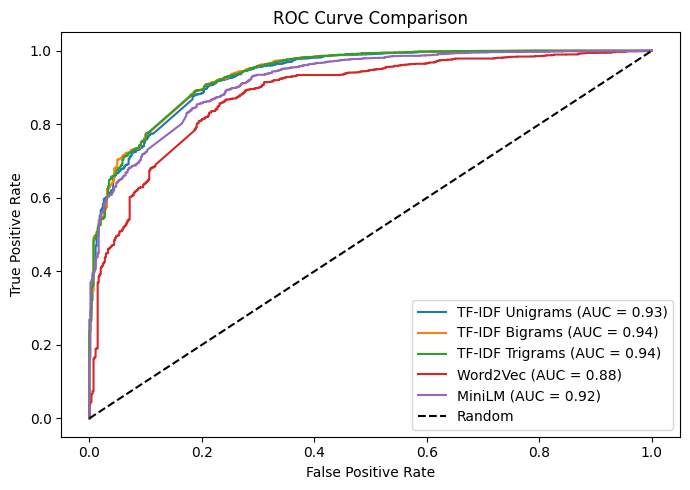

,Model,Accuracy,Precision (Neg),Recall (Neg),F1 (Neg)
0,TF-IDF Unigrams,0.887,0.586,0.789,0.672
1,TF-IDF Bigrams,0.895,0.616,0.774,0.686
2,TF-IDF Trigrams,0.896,0.619,0.771,0.687
3,Word2Vec,0.827,0.450,0.776,0.570
4,MiniLM,0.847,0.489,0.809,0.610


In [20]:
clf = SentimentClassifier()
clf.prepare_data(X, y)

clf.run_tfidf()
clf.run_tfidf_bigrams()
clf.run_tfidf_trigrams()
clf.run_word2vec()
clf.run_minilm()

clf.plot_roc_comparison()
clf.comparison_table()

## Fit Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

class SentimentClassifierRF:
    
    def __init__(self, test_size=0.2, random_state=42):
        self.test_size = test_size
        self.random_state = random_state
        self.results = {}
        self.roc_data = {}
        
    def prepare_data(self, X, y):
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
        )
        print(f"Train size: {len(self.X_train)} | Test size: {len(self.X_test)}")

    def _fit_predict(self, X_train_vec, X_test_vec, model_name):
        model = RandomForestClassifier(class_weight='balanced', n_estimators=100, 
                                       random_state=self.random_state, n_jobs=-1)
        model.fit(X_train_vec, self.y_train)
        y_pred = model.predict(X_test_vec)
        y_prob = model.predict_proba(X_test_vec)[:, 1]

        report = classification_report(self.y_test, y_pred, output_dict=True)
        self.results[model_name] = {
            'accuracy':           accuracy_score(self.y_test, y_pred),
            'precision_negative': report['0']['precision'],
            'recall_negative':    report['0']['recall'],
            'f1_negative':        report['0']['f1-score'],
            'y_pred':             y_pred,
        }
        fpr, tpr, _ = roc_curve(self.y_test, y_prob)
        self.roc_data[model_name] = {
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc_score(self.y_test, y_prob)
        }

        return model

    def run_tfidf(self):
        print("=== TF-IDF (Unigrams) ===")
        vectorizer = TfidfVectorizer()
        X_train_vec = vectorizer.fit_transform(self.X_train)
        X_test_vec  = vectorizer.transform(self.X_test)
        self.tfidf_vectorizer = vectorizer
        self.tfidf_model = self._fit_predict(X_train_vec, X_test_vec, 'TF-IDF Unigrams')

    def run_tfidf_bigrams(self):
        print("=== TF-IDF (Unigrams + Bigrams) ===")
        vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        X_train_vec = vectorizer.fit_transform(self.X_train)
        X_test_vec  = vectorizer.transform(self.X_test)
        self.tfidf_bigram_vectorizer = vectorizer
        self.tfidf_bigram_model = self._fit_predict(X_train_vec, X_test_vec, 'TF-IDF Bigrams')

    def run_tfidf_trigrams(self):
        print("=== TF-IDF (Unigrams + Bigrams + Trigrams) ===")
        vectorizer = TfidfVectorizer(ngram_range=(1, 3))
        X_train_vec = vectorizer.fit_transform(self.X_train)
        X_test_vec  = vectorizer.transform(self.X_test)
        self.tfidf_trigram_vectorizer = vectorizer
        self.tfidf_trigram_model = self._fit_predict(X_train_vec, X_test_vec, 'TF-IDF Trigrams')

    def run_word2vec(self):
        print("=== Word2Vec ===")
        X_train_tokens = [text.split() for text in self.X_train]
        X_test_tokens  = [text.split() for text in self.X_test]

        w2v = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5,
                       min_count=1, workers=4, seed=self.random_state)
        self.w2v_model = w2v

        def avg_vector(tokens, size=100):
            vecs = [w2v.wv[w] for w in tokens if w in w2v.wv]
            return np.mean(vecs, axis=0) if vecs else np.zeros(size)

        X_train_vec = np.array([avg_vector(t) for t in X_train_tokens])
        X_test_vec  = np.array([avg_vector(t) for t in X_test_tokens])
        self.w2v_model_rf = self._fit_predict(X_train_vec, X_test_vec, 'Word2Vec')

    def run_minilm(self):
        print("=== MiniLM ===")
        st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
        self.st_model = st_model

        print("Encoding X_train...")
        X_train_vec = st_model.encode(self.X_train.tolist(), batch_size=32, show_progress_bar=True)
        print("Encoding X_test...")
        X_test_vec  = st_model.encode(self.X_test.tolist(),  batch_size=32, show_progress_bar=True)
        self.minilm_model_rf = self._fit_predict(X_train_vec, X_test_vec, 'MiniLM')

    def plot_roc_comparison(self):
        plt.figure(figsize=(7, 5))
        for name, data in self.roc_data.items():
            plt.plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['auc']:.2f})")
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve Comparison - Random Forest')
        plt.legend()
        plt.tight_layout()
        plt.show()

    def comparison_table(self):
        rows = []
        for name, metrics in self.results.items():
            rows.append({
                'Model':           name,
                'Accuracy':        metrics['accuracy'],
                'Precision (Neg)': metrics['precision_negative'],
                'Recall (Neg)':    metrics['recall_negative'],
                'F1 (Neg)':        metrics['f1_negative'],
            })
        return pd.DataFrame(rows).round(3)

Train size: 14765 | Test size: 3692
=== TF-IDF (Unigrams) ===
=== TF-IDF (Unigrams + Bigrams) ===
=== TF-IDF (Unigrams + Bigrams + Trigrams) ===
=== Word2Vec ===
=== MiniLM ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3590.15it/s]


Encoding X_train...


Batches: 100%|██████████| 462/462 [00:28<00:00, 16.35it/s]


Encoding X_test...


Batches: 100%|██████████| 116/116 [00:07<00:00, 15.01it/s]


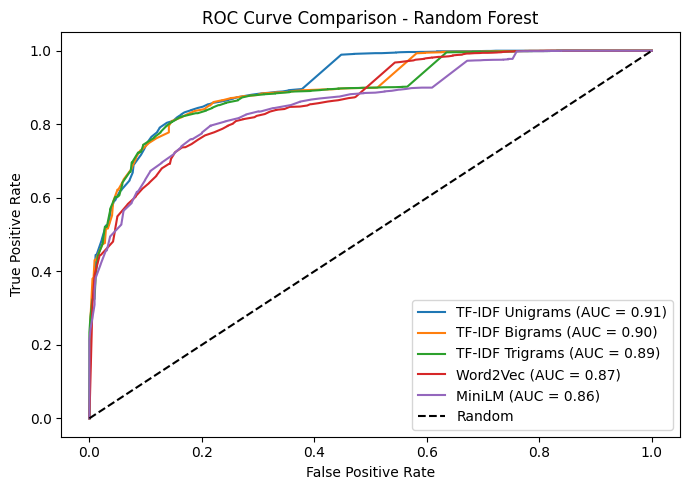

,Model,Accuracy,Precision (Neg),Recall (Neg),F1 (Neg)
0,TF-IDF Unigrams,0.911,0.954,0.418,0.582
1,TF-IDF Bigrams,0.896,0.955,0.310,0.468
2,TF-IDF Trigrams,0.891,0.950,0.277,0.429
3,Word2Vec,0.894,0.785,0.389,0.520
4,MiniLM,0.885,0.962,0.233,0.375


In [22]:
rf = SentimentClassifierRF()
rf.prepare_data(X, y)

rf.run_tfidf()
rf.run_tfidf_bigrams()
rf.run_tfidf_trigrams()
rf.run_word2vec()
rf.run_minilm()

rf.plot_roc_comparison()
rf.comparison_table()

## Fit SVM

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

class SentimentClassifierSVM:
    
    def __init__(self, test_size=0.2, random_state=42):
        self.test_size = test_size
        self.random_state = random_state
        self.results = {}
        self.roc_data = {}
        
    def prepare_data(self, X, y):
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
        )
        print(f"Train size: {len(self.X_train)} | Test size: {len(self.X_test)}")

    def _fit_predict(self, X_train_vec, X_test_vec, model_name):
        # CalibratedClassifierCV wraps LinearSVC to enable predict_proba for ROC curve
        model = CalibratedClassifierCV(
            LinearSVC(class_weight='balanced', max_iter=1000)
        )
        model.fit(X_train_vec, self.y_train)
        y_pred = model.predict(X_test_vec)
        y_prob = model.predict_proba(X_test_vec)[:, 1]

        report = classification_report(self.y_test, y_pred, output_dict=True)
        self.results[model_name] = {
            'accuracy':           accuracy_score(self.y_test, y_pred),
            'precision_negative': report['0']['precision'],
            'recall_negative':    report['0']['recall'],
            'f1_negative':        report['0']['f1-score'],
            'y_pred':             y_pred,
        }
        fpr, tpr, _ = roc_curve(self.y_test, y_prob)
        self.roc_data[model_name] = {
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc_score(self.y_test, y_prob)
        }

        return model

    def run_tfidf(self):
        print("=== TF-IDF (Unigrams) ===")
        vectorizer = TfidfVectorizer()
        X_train_vec = vectorizer.fit_transform(self.X_train)
        X_test_vec  = vectorizer.transform(self.X_test)
        self.tfidf_vectorizer = vectorizer
        self.tfidf_model = self._fit_predict(X_train_vec, X_test_vec, 'TF-IDF Unigrams')

    def run_tfidf_bigrams(self):
        print("=== TF-IDF (Unigrams + Bigrams) ===")
        vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        X_train_vec = vectorizer.fit_transform(self.X_train)
        X_test_vec  = vectorizer.transform(self.X_test)
        self.tfidf_bigram_vectorizer = vectorizer
        self.tfidf_bigram_model = self._fit_predict(X_train_vec, X_test_vec, 'TF-IDF Bigrams')

    def run_tfidf_trigrams(self):
        print("=== TF-IDF (Unigrams + Bigrams + Trigrams) ===")
        vectorizer = TfidfVectorizer(ngram_range=(1, 3))
        X_train_vec = vectorizer.fit_transform(self.X_train)
        X_test_vec  = vectorizer.transform(self.X_test)
        self.tfidf_trigram_vectorizer = vectorizer
        self.tfidf_trigram_model = self._fit_predict(X_train_vec, X_test_vec, 'TF-IDF Trigrams')

    def run_word2vec(self):
        print("=== Word2Vec ===")
        X_train_tokens = [text.split() for text in self.X_train]
        X_test_tokens  = [text.split() for text in self.X_test]

        w2v = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5,
                       min_count=1, workers=4, seed=self.random_state)
        self.w2v_model = w2v

        def avg_vector(tokens, size=100):
            vecs = [w2v.wv[w] for w in tokens if w in w2v.wv]
            return np.mean(vecs, axis=0) if vecs else np.zeros(size)

        X_train_vec = np.array([avg_vector(t) for t in X_train_tokens])
        X_test_vec  = np.array([avg_vector(t) for t in X_test_tokens])
        self.w2v_model_svm = self._fit_predict(X_train_vec, X_test_vec, 'Word2Vec')

    def run_minilm(self):
        print("=== MiniLM ===")
        st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
        self.st_model = st_model

        print("Encoding X_train...")
        X_train_vec = st_model.encode(self.X_train.tolist(), batch_size=32, show_progress_bar=True)
        print("Encoding X_test...")
        X_test_vec  = st_model.encode(self.X_test.tolist(),  batch_size=32, show_progress_bar=True)
        self.minilm_model_svm = self._fit_predict(X_train_vec, X_test_vec, 'MiniLM')

    def plot_roc_comparison(self):
        plt.figure(figsize=(7, 5))
        for name, data in self.roc_data.items():
            plt.plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['auc']:.2f})")
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve Comparison - LinearSVM')
        plt.legend()
        plt.tight_layout()
        plt.show()

    def comparison_table(self):
        rows = []
        for name, metrics in self.results.items():
            rows.append({
                'Model':           name,
                'Accuracy':        metrics['accuracy'],
                'Precision (Neg)': metrics['precision_negative'],
                'Recall (Neg)':    metrics['recall_negative'],
                'F1 (Neg)':        metrics['f1_negative'],
            })
        return pd.DataFrame(rows).round(3)

Train size: 14765 | Test size: 3692
=== TF-IDF (Unigrams) ===
=== TF-IDF (Unigrams + Bigrams) ===
=== TF-IDF (Unigrams + Bigrams + Trigrams) ===
=== Word2Vec ===
=== MiniLM ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3438.20it/s]


Encoding X_train...


Batches: 100%|██████████| 462/462 [00:39<00:00, 11.56it/s]


Encoding X_test...


Batches: 100%|██████████| 116/116 [00:07<00:00, 16.10it/s]


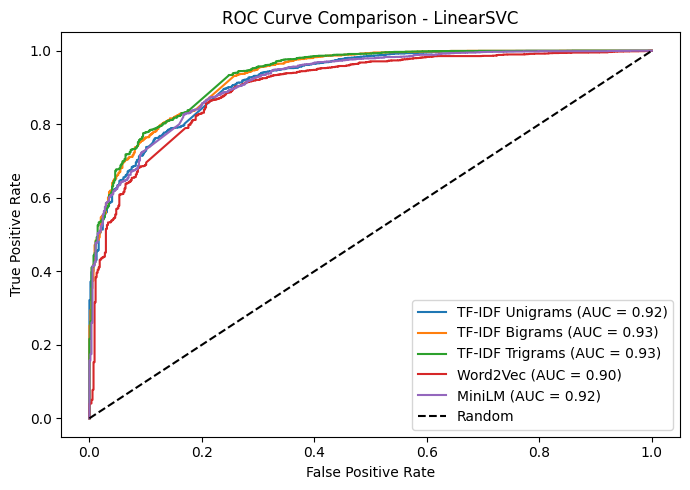

,Model,Accuracy,Precision (Neg),Recall (Neg),F1 (Neg)
0,TF-IDF Unigrams,0.915,0.823,0.545,0.656
1,TF-IDF Bigrams,0.925,0.826,0.626,0.712
2,TF-IDF Trigrams,0.924,0.786,0.668,0.722
3,Word2Vec,0.901,0.734,0.512,0.603
4,MiniLM,0.911,0.787,0.543,0.643


In [24]:
svm = SentimentClassifierSVM()
svm.prepare_data(X, y)

svm.run_tfidf()
svm.run_tfidf_bigrams()
svm.run_tfidf_trigrams()
svm.run_word2vec()
svm.run_minilm()

svm.plot_roc_comparison()
svm.comparison_table()

In [27]:
X = df_logistic['clean_text']
y = df_logistic['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Hyperparameter Tuning with Optuna

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
from sentence_transformers import SentenceTransformer

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── helper ───────────────────────────────────────────────────────────────────
def neg_recall(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return report['0']['recall']

# ── encode MiniLM once ───────────────────────────────────────────────────────
print("Encoding MiniLM embeddings...")
st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
X_train_bert = st_model.encode(X_train.tolist(), batch_size=32, show_progress_bar=True)
X_test_bert  = st_model.encode(X_test.tolist(),  batch_size=32, show_progress_bar=True)
print("Done encoding!")

# ── 1. Logistic Regression + TF-IDF Bigrams ──────────────────────────────────
def objective_lr_tfidf(trial):
    C            = trial.suggest_float('C', 0.01, 100, log=True)
    max_features = trial.suggest_int('max_features', 10000, 100000, step=10000)
    min_df       = trial.suggest_int('min_df', 1, 5)

    vectorizer  = TfidfVectorizer(ngram_range=(1, 2), max_features=max_features, min_df=min_df)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec  = vectorizer.transform(X_test)

    model = LogisticRegression(C=C, class_weight='balanced', max_iter=1000)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    return neg_recall(y_test, y_pred)

study_lr_tfidf = optuna.create_study(direction='maximize')
study_lr_tfidf.optimize(objective_lr_tfidf, n_trials=50)
print("Best params LR+TF-IDF Bigrams:", study_lr_tfidf.best_params)
print("Best Recall (Neg):", study_lr_tfidf.best_value)

# ── 2. Logistic Regression + MiniLM ──────────────────────────────────────────
def objective_lr_minilm(trial):
    C      = trial.suggest_float('C', 0.01, 100, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'saga', 'liblinear'])

    model = LogisticRegression(C=C, solver=solver, class_weight='balanced', max_iter=1000)
    model.fit(X_train_bert, y_train)
    y_pred = model.predict(X_test_bert)

    return neg_recall(y_test, y_pred)

study_lr_minilm = optuna.create_study(direction='maximize')
study_lr_minilm.optimize(objective_lr_minilm, n_trials=50)
print("Best params LR+MiniLM:", study_lr_minilm.best_params)
print("Best Recall (Neg):", study_lr_minilm.best_value)

# ── 3. LinearSVC + TF-IDF Bigrams ────────────────────────────────────────────
def objective_svm_bigrams(trial):
    C            = trial.suggest_float('C', 0.01, 100, log=True)
    max_features = trial.suggest_int('max_features', 10000, 100000, step=10000)
    min_df       = trial.suggest_int('min_df', 1, 5)

    vectorizer  = TfidfVectorizer(ngram_range=(1, 2), max_features=max_features, min_df=min_df)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec  = vectorizer.transform(X_test)

    model = CalibratedClassifierCV(LinearSVC(C=C, class_weight='balanced', max_iter=1000))
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    return neg_recall(y_test, y_pred)

study_svm_bigrams = optuna.create_study(direction='maximize')
study_svm_bigrams.optimize(objective_svm_bigrams, n_trials=50)
print("Best params SVM+TF-IDF Bigrams:", study_svm_bigrams.best_params)
print("Best Recall (Neg):", study_svm_bigrams.best_value)

# ── 4. LinearSVC + TF-IDF Trigrams ───────────────────────────────────────────
def objective_svm_trigrams(trial):
    C            = trial.suggest_float('C', 0.01, 100, log=True)
    max_features = trial.suggest_int('max_features', 10000, 100000, step=10000)
    min_df       = trial.suggest_int('min_df', 1, 5)

    vectorizer  = TfidfVectorizer(ngram_range=(1, 3), max_features=max_features, min_df=min_df)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec  = vectorizer.transform(X_test)

    model = CalibratedClassifierCV(LinearSVC(C=C, class_weight='balanced', max_iter=1000))
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    return neg_recall(y_test, y_pred)

study_svm_trigrams = optuna.create_study(direction='maximize')
study_svm_trigrams.optimize(objective_svm_trigrams, n_trials=50)
print("Best params SVM+TF-IDF Trigrams:", study_svm_trigrams.best_params)
print("Best Recall (Neg):", study_svm_trigrams.best_value)




Encoding MiniLM embeddings...


Batches: 100%|██████████| 116/116 [00:07<00:00, 16.50it/s]


Done encoding!
Best params LR+TF-IDF Bigrams: {'C': 0.010207270569582618, 'max_features': 40000, 'min_df': 1}
Best Recall (Neg): 0.8862385321100917
Best params LR+MiniLM: {'C': 0.010228432370608753, 'solver': 'saga'}
Best Recall (Neg): 0.8128440366972477


c:\Users\janne\Desktop\Big Blue Github Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\janne\Desktop\Big Blue Github Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\janne\Desktop\Big Blue Github Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\janne\Desktop\Big Blue Github Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\janne\Desktop\Big Blue Github Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best params SVM+TF-IDF Bigrams: {'C': 0.049128991171722466, 'max_features': 70000, 'min_df': 1}
Best Recall (Neg): 0.6568807339449542


c:\Users\janne\Desktop\Big Blue Github Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\janne\Desktop\Big Blue Github Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\janne\Desktop\Big Blue Github Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\janne\Desktop\Big Blue Github Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\janne\Desktop\Big Blue Github Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best params SVM+TF-IDF Trigrams: {'C': 0.05310713974294589, 'max_features': 100000, 'min_df': 1}
Best Recall (Neg): 0.6752293577981652


,Model,Tuned Recall (Neg),Tuned Precision (Neg),Tuned Accuracy,Tuned F1 (Neg)
0,LR + TF-IDF Bigrams,0.886,0.356,0.746,0.508
1,LR + MiniLM,0.813,0.405,0.796,0.540
2,SVM + TF-IDF Bigrams,0.657,0.812,0.927,0.726
3,SVM + TF-IDF Trigrams,0.675,0.785,0.925,0.726


## Choosing best Model 

In [35]:
def get_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Accuracy':        accuracy_score(y_true, y_pred),
        'Precision (Neg)': report['0']['precision'],
        'Recall (Neg)':    report['0']['recall'],
        'F1 (Neg)':        report['0']['f1-score'],
    }

# 1. LR + TF-IDF Bigrams
p = study_lr_tfidf.best_params
vec = TfidfVectorizer(ngram_range=(1,2), max_features=p['max_features'], min_df=p['min_df'])
X_train_vec = vec.fit_transform(X_train)
X_test_vec  = vec.transform(X_test)
m = LogisticRegression(C=p['C'], class_weight='balanced', max_iter=1000)
m.fit(X_train_vec, y_train)
tuned_lr_tfidf = get_metrics(y_test, m.predict(X_test_vec))

# 2. LR + MiniLM
p = study_lr_minilm.best_params
m = LogisticRegression(C=p['C'], solver=p['solver'], class_weight='balanced', max_iter=1000)
m.fit(X_train_bert, y_train)
tuned_lr_minilm = get_metrics(y_test, m.predict(X_test_bert))

# 3. SVM + TF-IDF Bigrams
p = study_svm_bigrams.best_params
vec = TfidfVectorizer(ngram_range=(1,2), max_features=p['max_features'], min_df=p['min_df'])
X_train_vec = vec.fit_transform(X_train)
X_test_vec  = vec.transform(X_test)
m = CalibratedClassifierCV(LinearSVC(C=p['C'], class_weight='balanced', max_iter=1000))
m.fit(X_train_vec, y_train)
tuned_svm_bigrams = get_metrics(y_test, m.predict(X_test_vec))

# 4. SVM + TF-IDF Trigrams
p = study_svm_trigrams.best_params
vec = TfidfVectorizer(ngram_range=(1,3), max_features=p['max_features'], min_df=p['min_df'])
X_train_vec = vec.fit_transform(X_train)
X_test_vec  = vec.transform(X_test)
m = CalibratedClassifierCV(LinearSVC(C=p['C'], class_weight='balanced', max_iter=1000))
m.fit(X_train_vec, y_train)
tuned_svm_trigrams = get_metrics(y_test, m.predict(X_test_vec))

results_comparison = pd.DataFrame([
    {
        'Model':           'LR + TF-IDF Bigrams',
        'Tuned Recall (Neg)':    study_lr_tfidf.best_value,
        'Tuned Precision (Neg)': tuned_lr_tfidf['Precision (Neg)'],
        'Tuned Accuracy':        tuned_lr_tfidf['Accuracy'],
        'Tuned F1 (Neg)':        tuned_lr_tfidf['F1 (Neg)'],
    },
    {
        'Model':           'LR + MiniLM',
        'Tuned Recall (Neg)':    study_lr_minilm.best_value,
        'Tuned Precision (Neg)': tuned_lr_minilm['Precision (Neg)'],
        'Tuned Accuracy':        tuned_lr_minilm['Accuracy'],
        'Tuned F1 (Neg)':        tuned_lr_minilm['F1 (Neg)'],
    },
    {
        'Model':           'SVM + TF-IDF Bigrams',
        'Tuned Recall (Neg)':    study_svm_bigrams.best_value,
        'Tuned Precision (Neg)': tuned_svm_bigrams['Precision (Neg)'],
        'Tuned Accuracy':        tuned_svm_bigrams['Accuracy'],
        'Tuned F1 (Neg)':        tuned_svm_bigrams['F1 (Neg)'],
    },
    {
        'Model':           'SVM + TF-IDF Trigrams',
        'Tuned Recall (Neg)':    study_svm_trigrams.best_value,
        'Tuned Precision (Neg)': tuned_svm_trigrams['Precision (Neg)'],
        'Tuned Accuracy':        tuned_svm_trigrams['Accuracy'],
        'Tuned F1 (Neg)':        tuned_svm_trigrams['F1 (Neg)'],
    },
]).round(3)

results_comparison

,Model,Tuned Recall (Neg),Tuned Precision (Neg),Tuned Accuracy,Tuned F1 (Neg)
0,LR + TF-IDF Bigrams,0.886,0.356,0.746,0.508
1,LR + MiniLM,0.813,0.404,0.796,0.540
2,SVM + TF-IDF Bigrams,0.657,0.812,0.927,0.726
3,SVM + TF-IDF Trigrams,0.675,0.785,0.925,0.726


## Save Models


In [34]:
import joblib
import os

os.makedirs(r'..\models', exist_ok=True)

# ── 1. LR + TF-IDF Bigrams ───────────────────────────────────────────────────
p = study_lr_tfidf.best_params
vec_lr_tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=p['max_features'], min_df=p['min_df'])
X_train_vec = vec_lr_tfidf.fit_transform(X_train)
model_lr_tfidf = LogisticRegression(C=p['C'], class_weight='balanced', max_iter=1000)
model_lr_tfidf.fit(X_train_vec, y_train)

joblib.dump(model_lr_tfidf, r'..\models\model_lr_tfidf.pkl')
joblib.dump(vec_lr_tfidf,   r'..\models\vectorizer_lr_tfidf.pkl')
print("Saved LR + TF-IDF Bigrams")

# ── 2. LR + MiniLM ───────────────────────────────────────────────────────────
p = study_lr_minilm.best_params
model_lr_minilm = LogisticRegression(C=p['C'], solver=p['solver'], class_weight='balanced', max_iter=1000)
model_lr_minilm.fit(X_train_bert, y_train)

joblib.dump(model_lr_minilm, r'..\models\model_lr_minilm.pkl')
joblib.dump(st_model,        r'..\models\minilm_encoder.pkl')
print("Saved LR + MiniLM")

Saved LR + TF-IDF Bigrams
Saved LR + MiniLM
